In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Car details v3.csv')

In [5]:
df.head(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0


In [6]:
df.shape

(8128, 13)

In [7]:
df.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
mileage,object
engine,object


In [8]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [9]:
df['mileage'] = df['mileage'].str.split().str[0]
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

df['engine'] = df['engine'].str.split().str[0]
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')

df['max_power'] = df['max_power'].str.split().str[0]
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [10]:
df.select_dtypes(include=['int64', 'float64']).corr()

,year,selling_price,km_driven,mileage,engine,max_power,seats
year,1.000000,0.414092,-0.418006,0.329145,0.018848,0.226320,-0.009144
selling_price,0.414092,1.000000,-0.225534,-0.126054,0.455734,0.748489,0.041358
km_driven,-0.418006,-0.225534,1.000000,-0.173073,0.205914,-0.038075,0.227336
mileage,0.329145,-0.126054,-0.173073,1.000000,-0.575831,-0.374621,-0.452085
engine,0.018848,0.455734,0.205914,-0.575831,1.000000,0.703975,0.610309
max_power,0.226320,0.748489,-0.038075,-0.374621,0.703975,1.000000,0.191999
seats,-0.009144,0.041358,0.227336,-0.452085,0.610309,0.191999,1.000000


In [11]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [12]:
df['mileage'] = df['mileage'].fillna(df['mileage'].median())
df['max_power'] = df['max_power'].fillna(df['max_power'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])
df = df.drop(columns=['torque'])

In [14]:
df[['fuel']].value_counts()

,count
fuel,
Diesel,4402
Petrol,3631
CNG,57
LPG,38


In [15]:
df['transmission'] = df['transmission'].map({'Manual': 0, 'Automatic': 1})
df['owner'] = df['owner'].map({'First Owner': 0, 'Second Owner': 1, 'Third Owner': 2, 'Fourth & Above Owner': 3, 'Test Drive Car': 4})
df = pd.get_dummies(df, columns=['fuel', 'seller_type'], drop_first=True, dtype=int)

In [21]:
df['brand'] = df['name'].str.split().str[0]
df = pd.get_dummies(df, columns=['brand'], drop_first=True, dtype=int)
df = df.drop(columns=['name'])
df['car_age'] = 2026 - df['year']
df = df.drop(columns=['year'])

In [22]:
df.head(3)

,name,year,selling_price,km_driven,transmission,owner,mileage,engine,max_power,seats,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,Maruti Swift Dzire VDI,2014,450000,145500,0,0,23.40,1248.0,74.00,5.0,...,0,0,0,0,0,0,0,0,0,0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,0,1,21.14,1498.0,103.52,5.0,...,0,0,0,0,0,1,0,0,0,0
2,Honda City 2017-2020 EXi,2006,158000,140000,0,2,17.70,1497.0,78.00,5.0,...,0,0,0,0,0,0,0,0,0,0


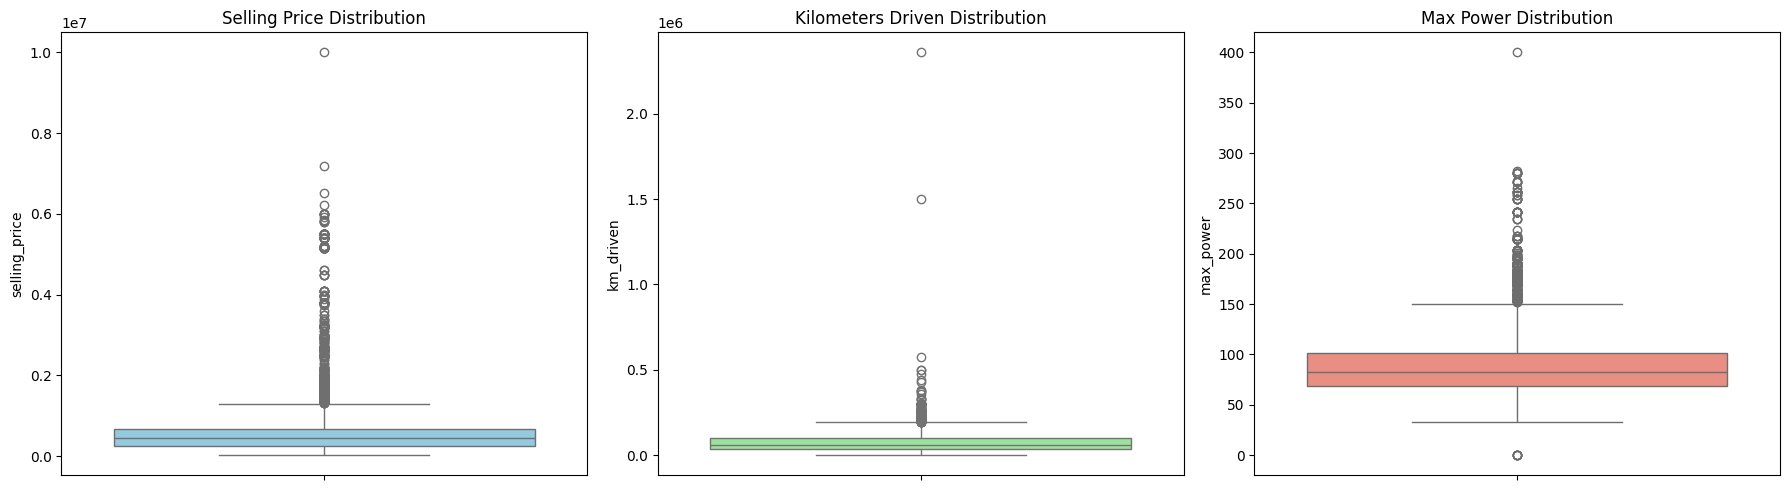

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, y='selling_price', ax=axes[0], color='skyblue')
axes[0].set_title('Selling Price Distribution')

sns.boxplot(data=df, y='km_driven', ax=axes[1], color='lightgreen')
axes[1].set_title('Kilometers Driven Distribution')

sns.boxplot(data=df, y='max_power', ax=axes[2], color='salmon')
axes[2].set_title('Max Power Distribution')

plt.tight_layout()
plt.show()

In [25]:
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['selling_price'] < upper_bound) & (df['selling_price'] > lower_bound) & (df['km_driven'] < 1000000) & (df['max_power'] < 350) & (df['max_power'] > 50)]

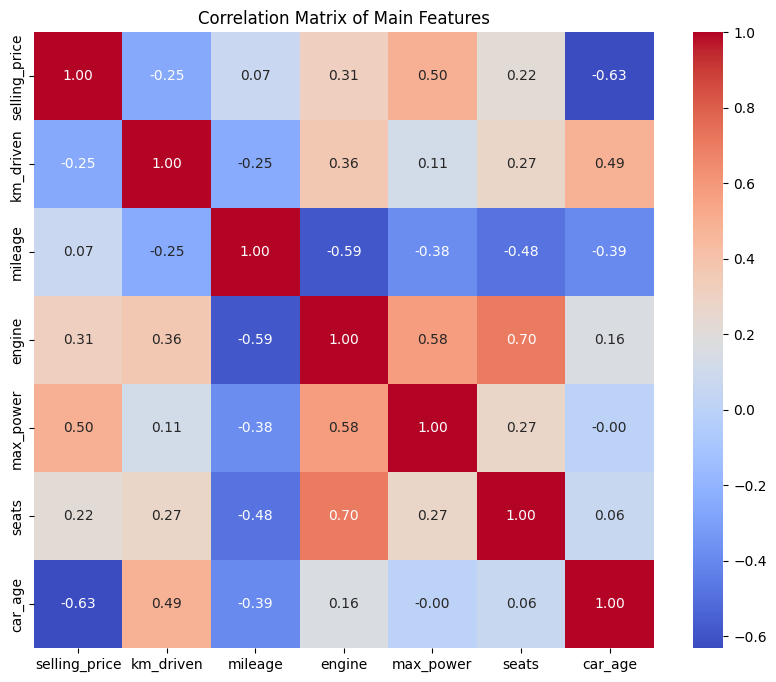

In [27]:
numeric_cols = ['selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'car_age']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Main Features')
plt.show()

In [28]:
np.random.seed(42)
df_shuffled = df.sample(frac=1).reset_index(drop=True)
train_size = int(0.8 * len(df_shuffled))
train_df = df_shuffled.iloc[:train_size].copy()
test_df = df_shuffled.iloc[train_size:].copy()

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

In [29]:
print(f"Train data saved: {train_df.shape}")
print(f"Test data saved: {test_df.shape}")

Train data saved: (5634, 76)
Test data saved: (1409, 76)
